# ANALIZA PODATKOV O FILMIH

Preučila bom različne podatke za izbranih 30 filmov, ki so se pojavljali na lestvici *Daily Box Office for 2026*. Analizirala bom njihov dnevni in povprečni dnevni zaslužek, trajanje, distributerja, žanre ter število dni, ko so bili na prvem mestu.


In [13]:
import pandas as pd
import matplotlib.pyplot as plt

In [14]:
filmi = pd.read_csv('podatki/seznam_filmov_dopolnjeno.csv')
filmi.head()

,naslov,distributer,trajanje,žanri,št. dni na 1. mestu,največji dnevni zaslužek
0,Spider-Man: Brand New Day,Sony Pictures Releasing,2 hr 25 min,"akcijski, pustolovski, znanstvenofantastični",23,169843039
1,Insidious: Out of the Further,Sony Pictures Releasing,1 hr 46 min,"grozljivka, skrivnostni, triler",1,10675888
2,The Odyssey,Universal Pictures,2 hr 52 min,"akcijski, pustolovski, fantazijski",14,50977435
3,Moana,Walt Disney Studios Motion Pictures,1 hr 55 min,"akcijski, pustolovski, komedija, družinski, fa...",7,18510043
4,Minions & Monsters,Universal Pictures,1 hr 30 min,"pustolovski, animirani, komedija, družinski",9,16506115


In [15]:
filmi.shape

(30, 6)

*1. Ali obstaja povezava med največjim dnevnim zaslužkom filma in številom dni, ko je bil film na prvem mestu lestivice?*

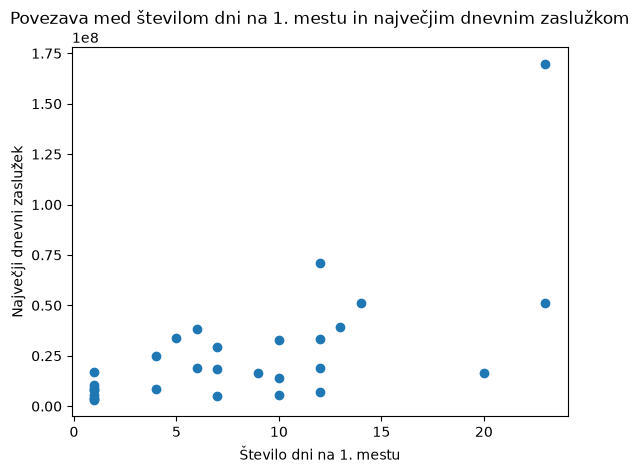

In [16]:
plt.scatter(
    filmi["št. dni na 1. mestu"],
    filmi["največji dnevni zaslužek"]
)

plt.xlabel("Število dni na 1. mestu")
plt.ylabel("Največji dnevni zaslužek")
plt.title(
    "Povezava med številom dni na 1. mestu "
    "in največjim dnevnim zaslužkom"
)

plt.show()

Med številom dni na prvem mestu lestivice in največjim dnevnim zaslužkom je opazna pozitivna povezava. Vendar povezava ni popolna, saj se pri filmih z enakim ali podobnim številom dni na prvem mestu največji dnevni zaslužek lahko precej razlikuje. Ocenim lahko, da za večino filmov večji zaslužek pomeni višje število dni na prvem mestu. Filmi, ki so se na prvo mesto uvrstili samo za en dan, imajo praviloma nižji največji dnevni zaslužek kot filmi, ki so bili na lestvici več kot en dan. 
Na grafu posebej izstopata filma na skrajno desni strani, ki sta bila največ dni na prvem mestu, vendar se njuna največja dnevna zaslužka precej razlikujeta. Sklepam lahko torej, da število dni na prvem mestu ne določa višine največjega dnevnega zaslužka. Na uspešnost filma vplivajo tudi drugi dejanviki, nekatere od teh bom raziskala v nadaljevanju naloge.

*2.1 Kateri žanri se najpogosteje pojavljajo med izbranimi filmi?*

In [17]:
zanri = filmi["žanri"].str.split(",").explode().str.strip()

tabela_zanrov = (zanri.value_counts().reset_index())

tabela_zanrov.columns = ["Žanr", "Število filmov"]

tabela_zanrov

,Žanr,Število filmov
0,pustolovski,15
1,znanstvenofantastični,12
2,komedija,12
3,drama,10
4,akcijski,9
5,grozljivka,9
6,triler,9
7,družinski,8
8,fantazijski,7
9,animirani,7


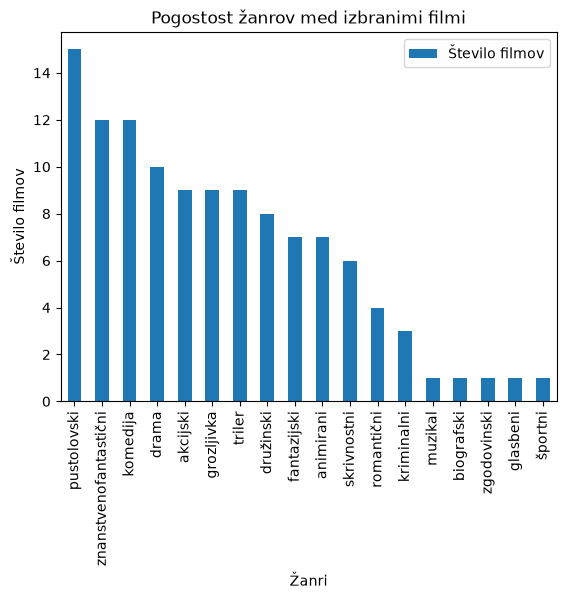

In [22]:
tabela_zanrov.plot(x="Žanr", y="Število filmov", kind="bar")
plt.xlabel("Žanri")
plt.ylabel("Število filmov")
plt.title("Pogostost žanrov med izbranimi filmi")
plt.show()

Za prikaz pogostosti posameznih žanrov sem uporabila stolpični diagram, ker omogoča pregledno primerjavo števila pojavitev med velikim številom kategorij.
Med izbranimi filmi je najpogosteje zastopan pustolovski žanr, ki se pojavi pri 15 filmih. Sledita znanstvenofantastični žanr in komedija z 12 pojavitvami, nato drama z desetimi. Žanri kot so muzikal, biografski, zgodovinski, glasbeni in športni, se pojavijo le enkrat. To kaže na neenakomerno zastopanost žanrov v izbranem vzorcu. Med pogostejšimi so tudi akcijski, pustolovski in znanstvenofantastični žanr, ki se lahko pri posameznem filmu med seboj prepletajo, saj imajo nekateri filmi več navedenih žanrov. Pudariti moram, da rezultati opisujejo predvsem značilnosti izbranih 30 filmov in jih ne moremo neposredno posplošiti na vse filme. Ker imajo nekateri filmi več žanrov se ponuja naslednje vprašanje.

*2.2 Kako pogosto se pojavljajo kombinacije žanrov pri izbranem naboru filmov in kateri pari žanrov se najpogosteje pojavljajo skupaj?*

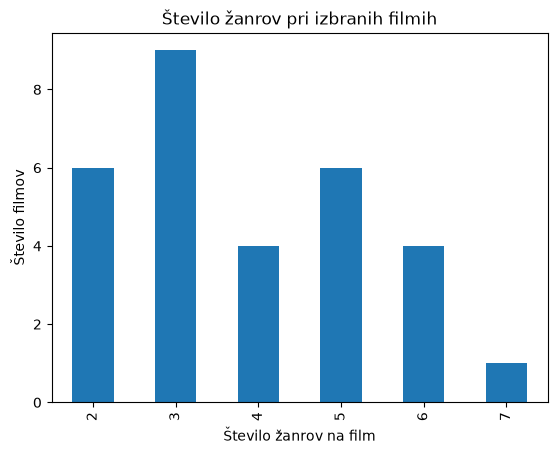

In [25]:
stevilo_zanrov_na_film = filmi["žanri"].str.split(",").str.len()
stevilo_zanrov_na_film.value_counts().sort_index().plot(kind="bar")

plt.xlabel("Število žanrov na film")
plt.ylabel("Število filmov")
plt.title("Število žanrov pri izbranih filmih")

plt.show()

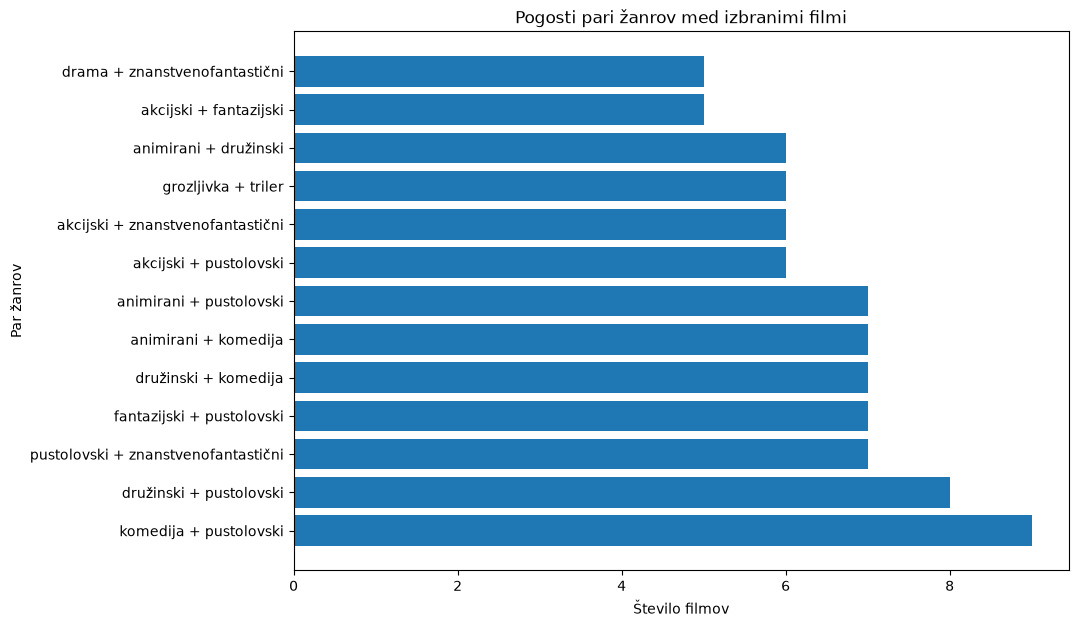

In [27]:
from itertools import combinations
from collections import Counter

pari_zanrov = []

for zanri_filma in filmi["žanri"]:
    seznam_zanrov = [z.strip() for z in zanri_filma.split(",")]
    pari = list(combinations(sorted(seznam_zanrov), 2))
    pari_zanrov.extend(pari)

stevilo_parov = Counter(pari_zanrov)

pogosti_pari = [(par, stevilo) for par, stevilo in stevilo_parov.items() if stevilo >= 5]

pogosti_pari = sorted(pogosti_pari, key=lambda x: x[1], reverse=True)

oznake = [f"{a} + {b}" for (a, b), stevilo in pogosti_pari]
vrednosti = [stevilo for (a, b), stevilo in pogosti_pari]

plt.figure(figsize=(10, 7))
plt.barh(oznake, vrednosti)
plt.xlabel("Število filmov")
plt.ylabel("Par žanrov")
plt.title("Pogosti pari žanrov med izbranimi filmi")

plt.show()

Kaže, da izbrani filmi niso omejeni na en sam žanr, temveč imajo več kombinacij. Največ filmov, 9, jih ima tri žanre, po 6 filmov pa jih ima dva oziroma pet žanrov. Štirje filmi imajo štiri žanre, štirje šest žanrov, en film pa ima kar sedem različnih žanrskih oznak.
Pri analizi posameznih parov žanrov sem ugotovila, da se najpogosteje skupaj pojavljata komedija in pustolovski žanr, ki se pojavita pri 9 filmih. Sledita kombinaciji družinskega ter pustolovskega žanra z 8 pojavitvami. Več parov ima po 7 pojavitev, med drugim pustolovski in znanstvenofantastični, fantazijski in pustolovski ter družinski in komedija.
Pri tem izstopa predvsem pustolovski žanr, kar sem že potrdila z vprašanjem številka 2.1, ter je zelo pogosto prisoten v različnih komcinacijah žanrov, kot so komedija, družinski, znanstvenofantastični, fantazijski ali akcijski žanr. Skepam, da so filmi pogosto opisani z različnimi žanrskimi značilnostmi.


*3. Ali se trajanje filma razlikuje glede na pet najpogostejših kombinacij žanrov?*

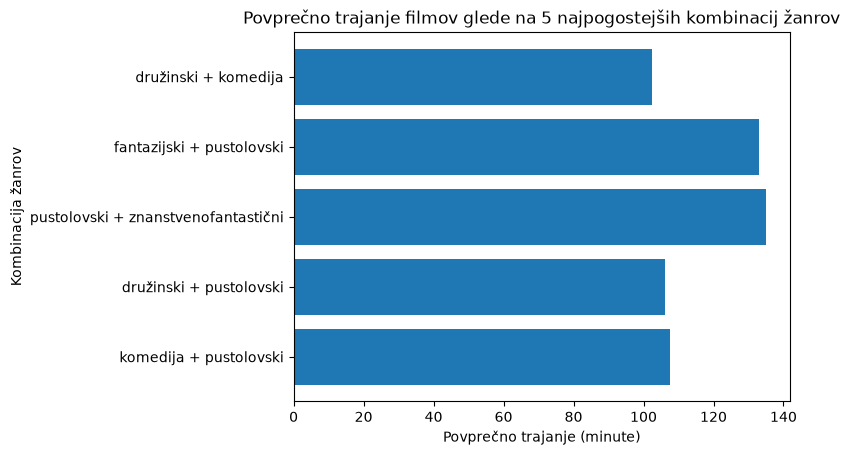

In [ ]:
trajanje_v_min = []

for cas in filmi["trajanje"]:
    deli = cas.split()
    ure = int(deli[0])
    minute = int(deli[2])
    trajanje_v_min.append(ure * 60 + minute)

filmi["trajanje_min"] = trajanje_v_min

povprecno_trajanje_parov = []

for (a, b), stevilo in pogosti_pari[:5]:
    trajanja = []

    for i, zanri in enumerate(filmi["žanri"]):
        if a in zanri and b in zanri:
            trajanja.append(filmi["trajanje_min"].iloc[i])

    povprecno_trajanje_parov.append(sum(trajanja) / len(trajanja))

oznake = [f"{a} + {b}" for (a, b), stevilo in pogosti_pari[:5]]
plt.barh(oznake, povprecno_trajanje_parov)

plt.xlabel("Povprečno trajanje (minute)")
plt.ylabel("Kombinacija žanrov")
plt.title("Povprečno trajanje filmov glede na 5 najpogostejših kombinacij žanrov")

plt.show()

Primerjala sem povprečno trajanje filmov glede na pet najpogostejših kombinacij žanrov, ki sem jih raziskala v točki 2.2. Rezultati kažejo, da se povprečno trajanje med posameznimi kombinacijami razlikuje. Izstopata kombinaciji fantazijski + pustolovski in pustolovski + znanstvenofantastični, pri katerih je povprečno trajanje približno 25-35 min daljše kot pri ostalih priljubljenih kombinacijah filmov.
Pri interpretaciji rezultatov je treba upoštevati, da ima posamezen film lahko več žanrov, zato se lahko isti film pojavi pri več analiziranih kombinacijah. Na primer, če ima film kombinacijo žanrov, ki se pojavi med petimi najpogostejšimi kombinacijami, lahko njegovo trajanje prispeva k povprečju več različnih kombinacij. Skupine zato niso popolnoma ločene in rezultatov ne smemo razumeti tako, da vsak film pripada samo eni kombinaciji.
Na podlagi grafa lahko zaključim, da so med izbranimi petimi kombinacijami najdaljši filmi povezani predvsem s kombinacijama fantazijskega in pustolovskega žanra ter pustolovskega in znanstvenofantastičnega žanra.